In [10]:
import os

### Feature Engineering Summary

- **Time-based features:** Added `Hour`, `Day`, dropped raw `Time`.  
- **Amount-based features:** Added log-transformed and scaled versions.  
- **Class imbalance:** Confirmed extreme imbalance (~0.17% fraud).  
- **Statistical insights:** Fraudulent transactions tend to have smaller medians, but some large outliers exist.  
- **PCA:** Reduced high-dimensional V-features into 2 components (`PCA1`, `PCA2`) for visualization & potential model input.  
- ✅ Saved fully processed dataset at `data/processed/creditcard_processed.csv`.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Install Kaggle API client
!pip install kaggle

# Make a directory for Kaggle and move the kaggle.json file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
# The dataset URL from the problem statement is: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Unzip the downloaded file
!unzip creditcardfraud.zip

# Load the dataset into a pandas DataFrame
df = pd.read_csv('creditcard.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 118MB/s] 

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
First 5 rows of the dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.1

In [3]:
# Extract Hour (time of day)
df["Hour"] = (df["Time"] // 3600) % 24

# Day (every 24h)
df["Day"] = (df["Time"] // (3600*24))

# Drop raw Time column
df = df.drop(columns=["Time"])

In [4]:
# Log transform
df["Amount_log"] = np.log1p(df["Amount"])

# Scale Amount & Amount_log (keep both for flexibility)
scaler = StandardScaler()
df[["Amount_scaled", "Amount_log_scaled"]] = scaler.fit_transform(df[["Amount", "Amount_log"]])

/tmp/ipykernel_7117/2423256977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, palette=["skyblue", "red"])


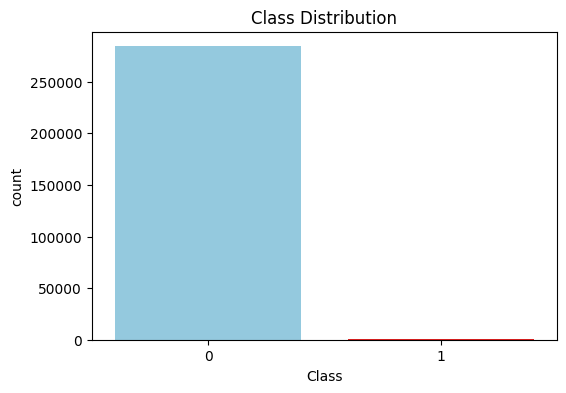

Fraudulent transactions: 0.173% of total


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df, palette=["skyblue", "red"])
plt.title("Class Distribution")
plt.show()

fraud_pct = (df["Class"].mean() * 100).round(3)
print(f"Fraudulent transactions: {fraud_pct}% of total")

In [6]:
print("Transaction Amount Summary:\n", df.groupby("Class")["Amount"].describe())
print("\nTransaction per Hour:\n", df.groupby("Hour")["Class"].mean().sort_values(ascending=False).head())

Transaction Amount Summary:
           count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87

Transaction per Hour:
 Hour
2.0    0.017127
4.0    0.010412
3.0    0.004868
5.0    0.003679
7.0    0.003175
Name: Class, dtype: float64


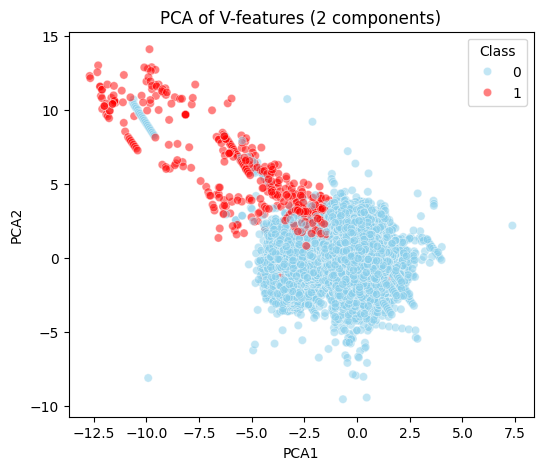

In [7]:
v_features = [col for col in df.columns if col.startswith("V")]

# Scale V-features before PCA
scaler_v = StandardScaler()
v_scaled = scaler_v.fit_transform(df[v_features])

# Apply PCA
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(v_scaled)

# Add back to dataframe
df["PCA1"] = df_pca[:, 0]
df["PCA2"] = df_pca[:, 1]

# Quick scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(x="PCA1", y="PCA2", hue="Class", data=df, alpha=0.5, palette={0:"skyblue",1:"red"})
plt.title("PCA of V-features (2 components)")
plt.show()


In [12]:
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, 'creditcard_processed.csv'), index=False)
print(f"✅ Processed dataset saved to {os.path.join(output_dir, 'creditcard_processed.csv')}")

✅ Processed dataset saved to ../data/processed/creditcard_processed.csv
